# 텐서플로우 버전 확인

In [1]:
import tensorflow as tf
import numpy as np

tf.__version__

'2.15.0'

# 예제 1

In [3]:
a = tf.constant(10)
b = tf.constant(20)

c = a + b
d = (a + b).numpy() # numpy() 메서드는 numpy 값을 리턴

print(type(c))
print(c)
print(type(d))
print(d)

d_numpy_to_tensor = tf.convert_to_tensor(d) # convert_to_tensor()는 numpy 값을 tensor 값으로 변환

print(type(d_numpy_to_tensor))
print(d_numpy_to_tensor)

<class 'tensorflow.python.framework.ops.EagerTensor'>
tf.Tensor(30, shape=(), dtype=int32)
<class 'numpy.int32'>
30
<class 'tensorflow.python.framework.ops.EagerTensor'>
tf.Tensor(30, shape=(), dtype=int32)


# 예제 2

In [5]:
W = tf.Variable(tf.random.normal([1]))
print('initial \ = ', W.numpy())
print('=' * 25)

# session 생성 없이 즉시 실행 (Eager Execution)
# numpy() 메서드 사용하면 numpy 값을 리턴

for step in range(2):
    W = W + 10
    print('step = ', step, 'W = ', W.numpy())

initial \ =  [0.8937975]
step =  0 W =  [10.893798]
step =  1 W =  [20.893799]


# 케라스

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD
import numpy as np

In [14]:
x_data = np.array([1, 2, 3, 4, 5, 6])
t_data = np.array([3, 4, 5, 6, 7, 8])

In [15]:
model = Sequential() 
model.add(Flatten(input_shape=(1,))) 

# 하나의 노드를 만듬, activation: 활성 함수 
# 선형회귀모델 linear 함수 사용, 
# 이진분류모델 binary_crossentropy(손실함수), => 시그모이드 함수 사용
# 다중분류모델 categorical_crossentropy(손실함수) => 소프트맥스 함수 사용
'''
model = Sequential()
model.add(Dense(1, activation='sigmoid'))  # 👉 확률 출력
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
'''
model.add(Dense(1, activation = 'linear')) 

model.compile(optimizer = SGD(learning_rate = 1e-2), loss = 'mse')
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 1)                 0         
                                                                 
 dense_3 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2 (8.00 Byte)
Trainable params: 2 (8.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# 모델 학습

In [17]:
hist = model.fit(x_data, t_data, epochs = 1000) # 모델 학습

Epoch 1/1000
1/1 [==============================] - 0s 16ms/step - loss: 2.9808e-04
Epoch 2/1000
1/1 [==============================] - 0s 11ms/step - loss: 2.9591e-04
Epoch 3/1000
1/1 [==============================] - 0s 7ms/step - loss: 2.9376e-04
Epoch 4/1000
1/1 [==============================] - 0s 8ms/step - loss: 2.9162e-04
Epoch 5/1000
1/1 [==============================] - 0s 10ms/step - loss: 2.8949e-04
Epoch 6/1000
1/1 [==============================] - 0s 8ms/step - loss: 2.8738e-04
Epoch 7/1000
1/1 [==============================] - 0s 7ms/step - loss: 2.8529e-04
Epoch 8/1000
1/1 [==============================] - 0s 10ms/step - loss: 2.8321e-04
Epoch 9/1000
1/1 [==============================] - 0s 2ms/step - loss: 2.8115e-04
Epoch 10/1000
1/1 [==============================] - 0s 14ms/step - loss: 2.7910e-04
Epoch 11/1000
1/1 [==============================] - 0s 8ms/step - loss: 2.7706e-04
Epoch 12/1000
1/1 [==============================] - 0s 9ms/step - loss: 2.7505e

In [19]:
hist # keras 객체 정보를 담고 있음

# 모델 시각화

In [18]:
hist.history # history에 loss값 저장 => 시각화 가능

{'loss': [0.0002980847784783691,
  0.0002959112753160298,
  0.0002937573881354183,
  0.0002916170924436301,
  0.0002894887875299901,
  0.00028738260152749717,
  0.0002852907928172499,
  0.00028320812270976603,
  0.0002811495214700699,
  0.0002791016304399818,
  0.00027706168475560844,
  0.000275047350442037,
  0.00027304247487336397,
  0.0002710547996684909,
  0.0002690777473617345,
  0.0002671174006536603,
  0.0002651733811944723,
  0.00026324097416363657,
  0.00026132140192203224,
  0.00025941579951904714,
  0.00025753118097782135,
  0.0002556537219788879,
  0.0002537921827752143,
  0.0002519417612347752,
  0.00025010350509546697,
  0.00024828201276250184,
  0.0002464721037540585,
  0.00024467584444209933,
  0.00024289307475555688,
  0.00024112174287438393,
  0.00023936443903949112,
  0.0002376201591687277,
  0.00023588888871017843,
  0.0002341728686587885,
  0.00023246339696925133,
  0.00023077001969795674,
  0.00022909104882273823,
  0.00022742028522770852,
  0.0002257664455100894,

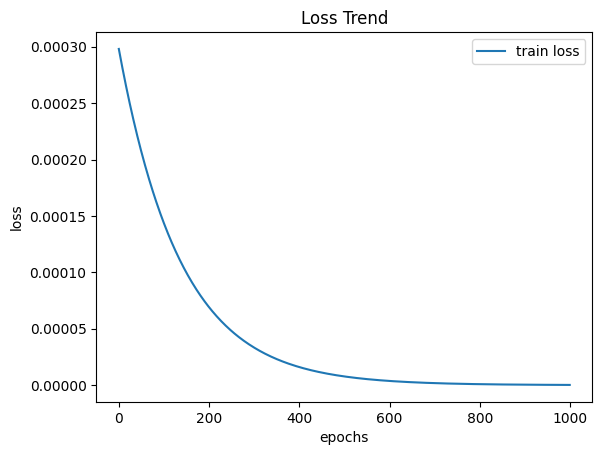

In [20]:
import matplotlib.pyplot as plt

plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')

plt.plot(hist.history['loss'], label = 'train loss')
plt.legend(loc = 'best')

plt.show()

# 모델 저장

In [24]:
model.save('model01.keras') # model.save('model01.h5')

In [25]:
model.save('model01.h5') # 에러 가능성 존재 케라스 확장자 권장

C:\Project\Python_Source\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# 모델 예측

In [26]:
pred = model.predict(x_data)

1/1 [==============================] - 0s 162ms/step


In [27]:
pred

array([[2.9992204],
       [3.9994583],
       [4.999696 ],
       [5.9999337],
       [7.000171 ],
       [8.000409 ]], dtype=float32)

In [32]:
from tensorflow.keras.models import load_model

load_model = load_model('model01.keras')

load_model.evaluate(x_data)

1/1 [==============================] - 0s 99ms/step - loss: 0.0000e+00


0.0

# 당뇨병 데이터를 활용해서 학습 예제

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adam
import numpy as np
import pandas as pd

In [36]:
loaded_data = np.loadtxt('./diabetes_nohead.csv', delimiter = ',')
loaded_data.shape

(768, 9)

In [38]:
seperation_rate = 0.3
test_data_num = int(len(loaded_data) * seperation_rate)

In [41]:
np.random.shuffle(loaded_data)

test_data = loaded_data[ 0:test_data_num ]

training_data = loaded_data[ test_data_num: ]
training_x_data = training_data[ :, 0:-1]
training_t_data = training_data[ :, [-1]]

test_x_data = test_data[ :, 0:-1 ]
test_t_data = test_data[ :, [-1]]

# 학습, 테스트 데이터 구조 파일
print('training_x_data.shape = ', training_x_data.shape)
print('training_t_data.shape = ', training_t_data.shape)

print('test_x_data.shape = ', test_x_data.shape)
print('test_t_data.shape = ', test_t_data.shape)

training_x_data.shape =  (538, 8)
training_t_data.shape =  (538, 1)
test_x_data.shape =  (230, 8)
test_t_data.shape =  (230, 1)


In [43]:
model = Sequential()

# 출력층
model.add(Dense(training_t_data.shape[1],
                input_shape = (training_x_data.shape[1],), # (538, 8) 8이 입력, 입력층
                activation = 'sigmoid')) # 이진분류 : sigmoid

model.compile(optimizer = SGD(learning_rate = 0.01),
              loss = 'binary_crossentropy', # 손실함수는 이진분류 : binary_crossentropy
              metrics = ['accuracy'])

model.summary()

# Total params: 9 이유는 학습할 입력 노드 수 8개, 출력 노드 수 1개로 총 9이다.

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 1)                 9         
                                                                 
Total params: 9 (36.00 Byte)
Trainable params: 9 (36.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [44]:
# 입력 데이터에서 0.2 val로 사용
hist = model.fit(
    training_x_data, 
    training_t_data, 
    epochs = 500, 
    validation_split = 0.2,
    batch_size = 32 # (538 * 0.8) / 32 = 14
)

Epoch 1/500



14/14 [==============================] - 0s 12ms/step - loss: 35.5222 - accuracy: 0.5558 - val_loss: 20.6238 - val_accuracy: 0.6574
Epoch 2/500
14/14 [==============================] - 0s 3ms/step - loss: 27.4606 - accuracy: 0.5488 - val_loss: 36.2528 - val_accuracy: 0.6574
Epoch 3/500
14/14 [==============================] - 0s 4ms/step - loss: 24.8472 - accuracy: 0.5651 - val_loss: 7.5131 - val_accuracy: 0.4722
Epoch 4/500
14/14 [==============================] - 0s 3ms/step - loss: 22.9338 - accuracy: 0.5628 - val_loss: 42.5120 - val_accuracy: 0.6481
Epoch 5/500
14/14 [==============================] - 0s 4ms/step - loss: 21.2006 - accuracy: 0.6116 - val_loss: 48.0966 - val_accuracy: 0.6574
Epoch 6/500
14/14 [==============================] - 0s 4ms/step - loss: 34.0517 - accuracy: 0.5279 - val_loss: 64.2795 - val_accuracy: 0.6574
Epoch 7/500
14/14 [==============================] - 0s 4ms/step - loss: 29.6135 - accuracy: 0.5512 - val_loss: 19.0371 - val_accuracy: 0.6574
Epoch 8/500

# 모델 평가

In [45]:
model.evaluate(test_x_data, test_t_data)

8/8 [==============================] - 0s 2ms/step - loss: 54.7655 - accuracy: 0.3478


[54.765525817871094, 0.3478260934352875]

In [46]:
hist.history

{'loss': [35.52219009399414,
  27.46061897277832,
  24.84716796875,
  22.933807373046875,
  21.200624465942383,
  34.05167770385742,
  29.61349105834961,
  20.1435546875,
  26.09748077392578,
  33.64033508300781,
  22.970247268676758,
  32.482357025146484,
  25.363712310791016,
  19.11140251159668,
  26.09108543395996,
  29.073650360107422,
  22.18157196044922,
  31.150754928588867,
  23.891633987426758,
  16.06691551208496,
  27.711429595947266,
  23.818708419799805,
  22.41555404663086,
  20.787052154541016,
  27.29637336730957,
  29.69748306274414,
  20.377243041992188,
  29.779830932617188,
  25.08656120300293,
  25.883228302001953,
  24.309139251708984,
  22.183347702026367,
  29.34426498413086,
  25.030513763427734,
  22.009511947631836,
  23.675582885742188,
  21.199241638183594,
  16.183015823364258,
  24.68301773071289,
  24.797582626342773,
  21.877071380615234,
  24.99271011352539,
  25.707122802734375,
  26.83943748474121,
  19.911813735961914,
  25.042203903198242,
  26.30

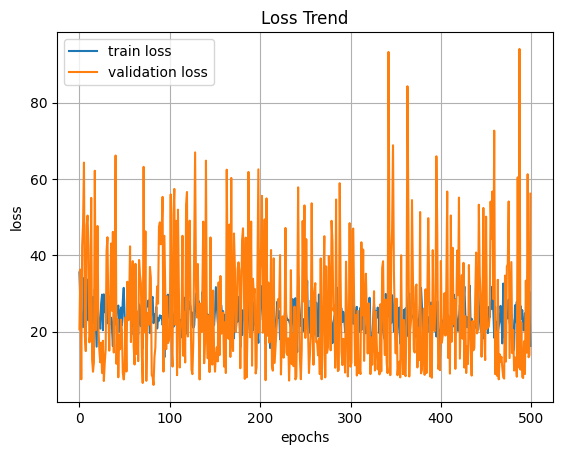

In [49]:
import matplotlib.pyplot as plt

plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')

plt.grid()

plt.plot(hist.history['loss'], label = 'train loss')
plt.plot(hist.history['val_loss'], label = 'validation loss')
    
plt.legend(loc = 'best')

plt.show()